# 5-Number Summary and Box Plot

Before learning **Handling Outliers**, you should understand the **5-Number Summary** because a **box plot is built from these five values**, and the **IQR method** for detecting outliers is based on them.

---

# 1. What problem does it solve?

The **5-Number Summary** provides a quick statistical summary of a dataset's distribution.

It helps us:

* Understand the spread of data.
* Detect outliers.
* Identify skewness.
* Build a box plot.
* Compare multiple datasets.

---

# 2. When should I use it?

Use it:

* Before outlier detection.
* During Exploratory Data Analysis (EDA).
* Before feature engineering.
* To compare distributions across datasets.

---

# 3. The Five Numbers

Suppose the data is:

```text
2 4 5 6 8 9 11 13 15
```

The five-number summary is:

| Statistic           | Meaning                           |
| ------------------- | --------------------------------- |
| Minimum             | Smallest value                    |
| Q1 (First Quartile) | 25% of data lies below this value |
| Median (Q2)         | Middle value (50%)                |
| Q3 (Third Quartile) | 75% of data lies below this value |
| Maximum             | Largest value                     |

Example:

| Statistic | Value |
| --------- | ----: |
| Minimum   |     2 |
| Q1        |   4.5 |
| Median    |     8 |
| Q3        |    12 |
| Maximum   |    15 |

---

# 4. Quartiles

Imagine sorting all observations.

```text
0%      25%       50%       75%      100%

|--------|---------|---------|---------|

Min      Q1      Median      Q3      Max
```

* **Q1** → 25th percentile
* **Median** → 50th percentile
* **Q3** → 75th percentile

---

# 5. Interquartile Range (IQR)

The **Interquartile Range (IQR)** measures the spread of the middle 50% of the data.

Formula:

[
\boxed{\text{IQR} = Q3 - Q1}
]

Example:

Q1 = 20

Q3 = 40

IQR = 40 − 20 = 20

---

# 6. Box Plot

A **box plot** is a graphical representation of the 5-number summary.

```text
                 Outlier

                    *

                    |

Min      Q1    Median    Q3      Max

|---------|======|======|---------|

           <---- Box ---->

```

### Parts

* Left Whisker → Minimum (excluding outliers)
* Left Box Edge → Q1
* Middle Line → Median
* Right Box Edge → Q3
* Right Whisker → Maximum (excluding outliers)
* Dots outside whiskers → Outliers

---

# 7. How are Outliers Found?

Lower Limit

[
Q1 - 1.5 \times IQR
]

Upper Limit

[
Q3 + 1.5 \times IQR
]

Any value outside these limits is considered an outlier.

Example:

Q1 = 20

Q3 = 40

IQR = 20

Lower Limit

20 − (1.5 × 20)

= −10

Upper Limit

40 + (1.5 × 20)

= 70

Values less than −10 or greater than 70 are outliers.

---

# 8. Python Code

```python
import pandas as pd

data = [2,4,5,6,8,9,11,13,15]

df = pd.DataFrame(data, columns=['Value'])

print(df.describe())
```

---

Box Plot

```python
import matplotlib.pyplot as plt

plt.boxplot(df['Value'])

plt.show()
```

---

# 9. Interview Questions

* What is the 5-number summary?
* What is Q1?
* What is Q3?
* What is IQR?
* Why is IQR preferred over range?
* What information does a box plot provide?
* How do you detect outliers using a box plot?

---

# 10. Common Mistakes

❌ Confusing Q1 with the minimum value.

❌ Assuming the whiskers always represent the minimum and maximum values (they typically extend only to the most extreme non-outlier values).

❌ Forgetting that IQR = Q3 − Q1.

❌ Assuming every point outside the whiskers is an error—some may be genuine extreme observations.

---

# 11. Real-World Examples

### Banking

Detect unusually large transactions that may indicate fraud.

### Healthcare

Identify abnormal blood pressure or glucose readings.

### E-commerce

Spot customers with unusually high spending.

### Manufacturing

Detect products with abnormal dimensions.

### Education

Find students with exceptionally high or low scores for further analysis.

---

# 12. Revision Box

```text
5-Number Summary

✔ Minimum
✔ Q1 (25%)
✔ Median (50%)
✔ Q3 (75%)
✔ Maximum

IQR = Q3 - Q1

Outlier Rule:

Lower = Q1 - 1.5 × IQR

Upper = Q3 + 1.5 × IQR

Box Plot

□ Left Edge  → Q1
│ Middle     → Median
□ Right Edge → Q3

Whiskers:
Most extreme non-outlier values

Dots outside whiskers:
Outliers
```

---

# Handling Outliers Using Python

---

# 1. What problem does it solve?

An **outlier** is a data point that is **significantly different from the rest of the observations**.

Example:

```text
10 12 14 15 16 18 20 150
```

Here, **150** is much larger than the other values and is an outlier.

### Problems caused by outliers

* Distort the mean.
* Increase variance.
* Reduce model accuracy.
* Mislead statistical analysis.
* Negatively affect distance-based algorithms (e.g., KNN, K-Means).

---

# 2. Why do outliers occur?

* Data entry mistakes
* Measurement errors
* Sensor malfunctions
* Fraudulent activity
* Rare but valid events
* Natural variation

---

# 3. When should I handle outliers?

Handle them:

* Before training sensitive models.
* During EDA.
* Before feature scaling.
* When they are due to errors or unnecessarily distort the analysis.

---

# 4. When should I NOT remove outliers?

* When they represent genuine rare events (e.g., fraud cases).
* When using tree-based models, which are generally robust to outliers.
* Without understanding why the outlier exists.

---

# 5. Types of Outliers

### A. Global Outlier

Very different from the entire dataset.

Example:

```text
5 6 7 8 9 100
```

---

### B. Contextual Outlier

Unusual only in a specific context.

Example:

* 25°C in winter may be unusual.
* 25°C in summer may be normal.

---

### C. Collective Outlier

A group of observations that is unusual together.

Common in:

* Time series
* Network traffic
* Fraud detection

---

# 6. Methods

## Method 1: IQR Method (Most Common)

Best for:

* Skewed distributions
* Non-normal data

Formula:

Lower Limit

Q1 − 1.5 × IQR

Upper Limit

Q3 + 1.5 × IQR

### Code

```python
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < lower) | (df['Salary'] > upper)]
```

---

## Method 2: Z-Score Method

Best for:

* Approximately normal distributions.

Formula

[
Z=\frac{x-\mu}{\sigma}
]

Common threshold:

| Z    | Meaning |
| ---- | ------- |
| > 3  | Outlier |
| < -3 | Outlier |

### Code

```python
from scipy import stats

z = stats.zscore(df['Salary'])

outliers = df[abs(z) > 3]
```

---

## Method 3: Percentile Method

Remove extreme values.

Example:

Keep:

* 1st percentile
* 99th percentile

Useful for very large datasets.

---

## Method 4: Winsorization

Instead of removing outliers, cap them at chosen percentile limits.

Example:

```text
Original

10 15 20 25 300

After Winsorization

10 15 20 25 100
```

This preserves all observations while reducing the influence of extreme values.

---

# 7. Decision Flow

```text
Outliers Found?

│

├── No

│      │

│      ▼

 Train Model

│

└── Yes

       │

       ▼

Are They Data Entry Errors?

│

├── Yes

│      ▼

Remove / Correct

│

└── No

       │

       ▼

Are They Genuine Rare Events?

│

├── Yes

│      ▼

Keep or Transform

│

└── No

       │

       ▼

Distribution?

├── Normal → Z-Score

└── Skewed → IQR

Need to Keep All Data?

├── Yes → Winsorization

└── No → Remove Outliers
```

---

# 8. Code

Remove Outliers using IQR

```python
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[
    (df['Salary'] >= lower) &
    (df['Salary'] <= upper)
]
```

---

# 9. Pros & Cons

| Method        | Pros                                          | Cons                                  |
| ------------- | --------------------------------------------- | ------------------------------------- |
| IQR           | Works well for skewed data                    | Less suitable for very small datasets |
| Z-Score       | Simple and effective for normal distributions | Sensitive to non-normal data          |
| Percentile    | Easy to implement                             | Threshold selection is subjective     |
| Winsorization | Retains all observations                      | Alters original values                |

---

# 10. Algorithm Compatibility

| Algorithm           | Sensitive to Outliers? |
| ------------------- | ---------------------- |
| Linear Regression   | ✅ Yes                  |
| Logistic Regression | ✅ Yes                  |
| KNN                 | ✅ Yes                  |
| K-Means             | ✅ Yes                  |
| SVM                 | ✅ Often                |
| Neural Networks     | ⚠️ Can be              |
| Decision Tree       | ❌ Generally robust     |
| Random Forest       | ❌ Generally robust     |
| XGBoost             | ❌ Generally robust     |

---

# 11. Interview Questions

### Basic

* What is an outlier?
* What causes outliers?
* Difference between an outlier and noise?

### Intermediate

* IQR vs. Z-Score?
* Why is IQR preferred for skewed data?
* What is Winsorization?

### Advanced

* Should you always remove outliers?
* Which algorithms are most sensitive to outliers?
* How do you handle outliers in fraud detection?

---

# 12. Common Mistakes

❌ Removing outliers without understanding their cause.

❌ Using the Z-score method on heavily skewed data.

❌ Removing rare but important events such as fraud cases.

❌ Detecting outliers before cleaning obvious data-entry errors.

❌ Ignoring domain knowledge when deciding whether to keep or remove outliers.

---

# 13. Real-World Examples

### Banking

Very large transactions may indicate fraud and should often be investigated rather than removed.

### Healthcare

An extremely high blood sugar reading may represent a critical patient condition, not a measurement error.

### Manufacturing

Products with abnormal dimensions may indicate production defects.

### Retail

Unusually large purchases during a sale may be valid and not necessarily outliers to remove.

### IoT

A faulty sensor may produce impossible values (e.g., -100°C), which should be corrected or removed.

---

# 14. Revision Box

```text
Outliers

✔ Extreme observations

Common Methods:
• IQR
• Z-Score
• Percentile
• Winsorization

Normal Data → Z-Score

Skewed Data → IQR

Formulas:

IQR = Q3 - Q1

Lower = Q1 - 1.5 × IQR

Upper = Q3 + 1.5 × IQR

Tree Models:
Usually robust to outliers

Interview Tip:
Never remove outliers blindly. Determine whether they are errors or meaningful rare events before deciding how to handle them.
```


In [1]:
import numpy as np

In [2]:
# Create a list named 'lst_marks' containing the students' marks/scores.
lst_marks = [45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]

# Calculate specific quantiles (percentiles) from the data using NumPy.
# np.quantile(data, q)
#   data -> lst_marks: the list of numerical values on which quantiles are calculated.
#   q -> [0, 0.25, 0.50, 0.75, 1.0]:
#        0     : 0th percentile (minimum value)
#        0.25  : 25th percentile (First Quartile, Q1)
#        0.50  : 50th percentile (Median)
#        0.75  : 75th percentile (Third Quartile, Q3)
#        1.0   : 100th percentile (maximum value)
#
# The returned quantile values are unpacked into five variables:
#   minimum  -> smallest value in the dataset
#   Q1       -> first quartile (25% of values are below this)
#   median   -> middle value (50th percentile)
#   Q3       -> third quartile (75% of values are below this)
#   maximum  -> largest value in the dataset
minimum, Q1, median, Q3, maximum = np.quantile(lst_marks, [0, 0.25, 0.50, 0.75, 1.0])

In [3]:
minimum

np.float64(32.0)

In [4]:
Q1

np.float64(54.0)

In [5]:
median

np.float64(67.0)

In [6]:
Q3

np.float64(89.0)

In [7]:
maximum

np.float64(99.0)

In [8]:
# Calculate the Interquartile Range (IQR).
# IQR = Q3 - Q1
#   Q3 -> Third Quartile (75th percentile)
#   Q1 -> First Quartile (25th percentile)
#
# The IQR measures the spread of the middle 50% of the data.
# It is commonly used to identify outliers and is less affected by extreme values.
IQR = Q3 - Q1

In [9]:
print(IQR)

35.0


In [10]:
# Calculate the lower fence for outlier detection.
# Formula: Q1 - 1.5 × IQR
#   Q1   -> First Quartile (25th percentile)
#   IQR  -> Interquartile Range (Q3 - Q1)
#   1.5  -> Standard multiplier used in the IQR method to detect outliers.
#
# Any value smaller than 'lower_fence' is considered a potential outlier.
lower_fence = Q1 - 1.5 * IQR

# Calculate the upper (higher) fence for outlier detection.
# Formula: Q3 + 1.5 × IQR
#   Q3   -> Third Quartile (75th percentile)
#   IQR  -> Interquartile Range
#   1.5  -> Standard multiplier used in the IQR method.
#
# Any value greater than 'higher_fence' is considered a potential outlier.
higher_fence = Q3 + 1.5 * IQR

In [11]:
# see the lower and higher fence value calculated
lower_fence, higher_fence

# Clearly, as per the values obtained there is no such outliers

(np.float64(1.5), np.float64(141.5))

In [12]:
# Now we will create the box plot for the same data
lst_marks = [45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]


In [13]:
!pip install --upgrade pandas seaborn numpy

<Axes: >

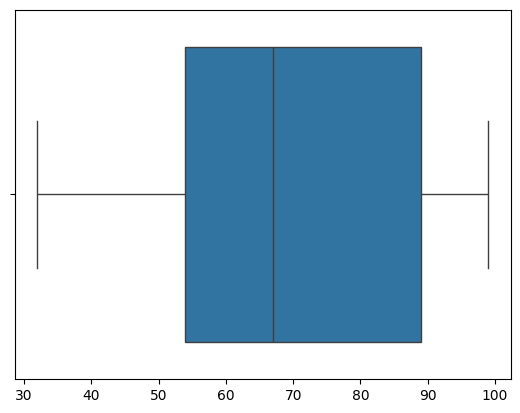

In [16]:
# Import the Seaborn library and assign it the alias 'sns'.
# Seaborn is a data visualization library built on top of Matplotlib,
# commonly used for creating attractive statistical plots.
import seaborn as sns

# Create a horizontal box plot using the values in 'lst_marks'.
# sns.boxplot(x=lst_marks)
#   x -> lst_marks:
#        Specifies that the values in 'lst_marks' should be plotted
#        along the x-axis.
#
# The box plot visually displays:
#   - Minimum value (excluding outliers)
#   - First Quartile (Q1 or 25th percentile)
#   - Median (50th percentile)
#   - Third Quartile (Q3 or 75th percentile)
#   - Maximum value (excluding outliers)
#   - Any outliers (shown as individual points beyond the whiskers)
#
# This plot helps identify the distribution, spread, skewness,
# and presence of outliers in the dataset.
sns.boxplot(x=lst_marks)

<Axes: >

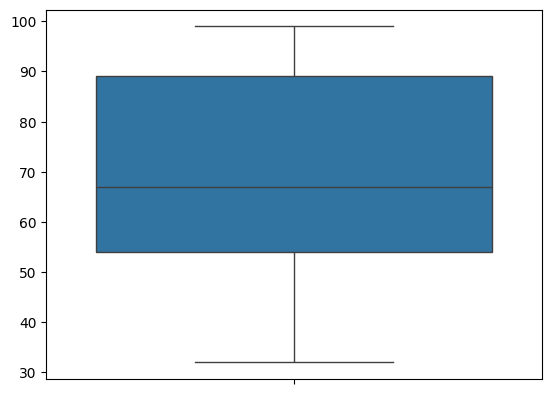

In [15]:
import seaborn as sns

# Pass the list directly to the y-axis
sns.boxplot(y=lst_marks)

In [ ]:
# Clearly, there is no outlier in the box plot

In [17]:
# Let's add some outliers

lst_marks = [-100, 45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74, 150]


<Axes: >

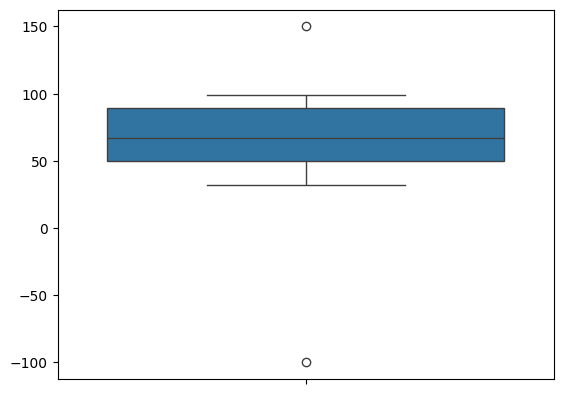

In [19]:
# again plotting

import seaborn as sns

# Pass the list directly to the y-axis
sns.boxplot(y=lst_marks)
# the dots are the outliers